In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


In [2]:

dataset_path = './datasets/Cyclone_Wildfire_Flood_Earthquake_Database'
categories = ['Cyclone', 'Flood', 'Wildfire', 'Earthquake']
data = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    
    # Ensure that it's a directory and not a file (e.g., readme.txt)
    if os.path.isdir(category_path):
        for img_file in os.listdir(category_path):
            img_path = os.path.join(category_path, img_file)
            
            # Only process image files and skip any non-image files
            if os.path.isfile(img_path) and img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                data.append({
                    'image_path': img_path,
                    'Category': category
                })

# Create DataFrame
df = pd.DataFrame(data)


In [3]:
train_df, test_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=42)


In [4]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.convnext.preprocess_input,
    validation_split=0.2)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.convnext.preprocess_input)

train_images = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='Category',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    subset='training',
    shuffle=True
)

val_images = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='Category',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    subset='validation',
    shuffle=True
)

test_images = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='Category',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False
)


Found 2480 validated image filenames belonging to 4 classes.
Found 619 validated image filenames belonging to 4 classes.
Found 1329 validated image filenames belonging to 4 classes.


In [5]:
base_model = tf.keras.applications.ConvNeXtXLarge(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False

inputs = base_model.input
x = Dense(128, activation='relu')(base_model.output)
outputs = Dense(4, activation='softmax')(x)  # 4 classes: Cyclone, Wildfire, Flood, Earthquake
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()



1393257616/1393257616 ━━━━━━━━━━━━━━━━━━━━ 591s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_prestem_norm… │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stem          │ (None, 56, 56, 256)       │          13,056 │ convnext_xlarge_prestem_n… │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 256)       │          12,800 │ convnext_xlarge_stem[0][0] │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 256)       │             512 │ convnext_xlarge_stage_0_b… │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 1024)      │         263,168 │ convnext_xlarge_stage_0_b… │
│ (Dense)                       │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 1024)      │               0 │ convnext_xlarge_stage_0_b… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 256)       │         262,400 │ convnext_xlarge_stage_0_b… │
│ (Dense)                       │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 256)       │             256 │ convnext_xlarge_stage_0_b… │
│ (LayerScale)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 256)       │               0 │ convnext_xlarge_stage_0_b… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 56, 56, 256)       │               0 │ convnext_xlarge_stem[0][0… │
│                               │                           │                 │ convnext_xlarge_stage_0_b… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convnext_xlarge_stage_0_bloc… │ (None, 56, 56, 256)       │          12,800 │ add[0][0]                  │
│ (Conv2D)                      │                           │               

 Total params: 348,410,756 (1.30 GB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 348,147,968 (1.30 GB)

In [6]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,  # Keep small for mini version
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)


Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4642s 59s/step - accuracy: 0.8912 - loss: 0.3171 - val_accuracy: 0.9790 - val_loss: 0.0831
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4880s 63s/step - accuracy: 0.9919 - loss: 0.0240 - val_accuracy: 0.9822 - val_loss: 0.0730
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 8067s 104s/step - accuracy: 0.9969 - loss: 0.0114 - val_accuracy: 0.9806 - val_loss: 0.0833
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5216s 67s/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9790 - val_loss: 0.0838
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 40193s 521s/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 0.9806 - val_loss: 0.0703
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3929s 50s/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 0.9806 - val_loss: 0.0870
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3816s 49s/step - accuracy: 1.0000 - loss: 7.7238e-04 - val_accuracy: 0.9790 - val_loss: 0.0790
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3820s 49s/step - accuracy: 1.0000 - loss: 3.9403e-04

In [9]:
test_loss, test_acc = model.evaluate(test_images)
print(f"Test Accuracy: {test_acc*100:.2f}%")


42/42 ━━━━━━━━━━━━━━━━━━━━ 2812s 67s/step - accuracy: 0.9608 - loss: 0.1280
Test Accuracy: 96.84%


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


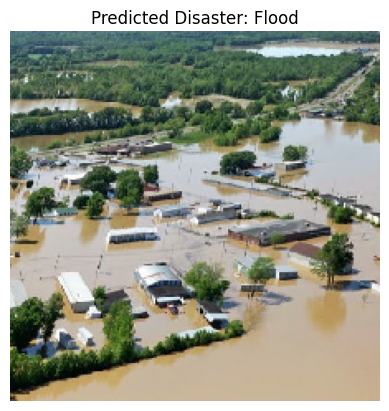

Prediction Probabilities: [[2.5408926e-09 1.7805235e-09 1.0000000e+00 2.2224060e-10]]


In [11]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_disaster(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.convnext.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # batch dimension
    
    prediction = model.predict(img_array)
    predicted_class = list(train_images.class_indices.keys())[np.argmax(prediction)]
    
    plt.imshow(img)
    plt.title(f"Predicted Disaster: {predicted_class}")
    plt.axis('off')
    plt.show()
    
    print(f"Prediction Probabilities: {prediction}")

# Example usage
predict_disaster('./image.jpg')
